# Análisis Pseudobulk: Células NK (General y por Subtipos)
Este notebook realiza un análisis diferencial de genes (Old vs Adult) en células Natural Killer (NK).
El análisis se divide en dos fases:
1. **Análisis General de Células NK**: Filtrado de artefactos técnicos (genes de inmunoglobulinas y receptores T) y análisis de expresión diferencial global.
2. **Análisis Profundo por Subtipos Celulares**: Evaluación dinámica de las diferencias de expresión en cada subpoblación de NK.


In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from pydeseq2.default_inference import DefaultInference
import os

# Configuración de gráficos
plt.rcParams['figure.figsize'] = [8, 6]
plt.rcParams['figure.dpi'] = 100
sc.settings.verbosity = 3

# Configuración de pandas para mostrar tablas completas
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Crear directorio para resultados
os.makedirs('results', exist_ok=True)


/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## 1. Análisis General de Células NK

In [2]:
# Cargar el dataset (pre-filtrado para excluir 'young')
adata = sc.read_h5ad('/app/project/restore_data/pipeline_articulo/old_vs_adult/4.models/scanvi_model/scanvi_sin_jovenes.h5ad')
print(f"Tamaño del dataset: {adata.n_obs} células, {adata.n_vars} genes.")
print(adata.obs['age_group'].value_counts())


Tamaño del dataset: 193701 células, 7000 genes.
age_group
adult    133527
old       60174
Name: count, dtype: int64


In [3]:
# Definir genes contaminantes (Inmunoglobulinas y Receptores de Células T)
# Estos genes suelen generar ruido técnico en células NK
genes_to_exclude = adata.var_names.str.startswith(('IGH', 'IGK', 'IGL', "TRAV", "TRAJ", "TRAC",
                                            "TRBV", "TRBD", "TRBJ", "TRBC",
                                            "TRGV", "TRGJ", "TRGC",
                                            "TRDV", "TRDJ", "TRDC"))

removed_genes_list = adata.var_names[genes_to_exclude].tolist()
print(f"Genes identificados para eliminar: {len(removed_genes_list)}")

# Filtrar el objeto adata
adata = adata[:, ~genes_to_exclude].copy()
print(f"Genes después del filtro: {adata.n_vars}")


Genes identificados para eliminar: 255
Genes después del filtro: 6745


In [4]:
# Crear perfiles pseudobulk agregando cuentas por donante
def create_pseudobulk(adata_subset):
    pseudobulk_profiles = []
    metadata = []
    
    # Agrupar por grupo de edad y donante
    for (age, donor), group in adata_subset.obs.groupby(['age_group', 'donor_id']):
        if len(group) == 0:
            continue
            
        cells_in_group = adata_subset[group.index]
        
        # Sumar la capa de 'counts' sin procesar
        if 'counts' in cells_in_group.layers:
            pseudobulk_counts = cells_in_group.layers['counts'].sum(axis=0)
        else:
            pseudobulk_counts = cells_in_group.X.sum(axis=0)
            
        # Convertir a matriz densa si es sparse
        if hasattr(pseudobulk_counts, 'toarray'):
            pseudobulk_counts = pseudobulk_counts.toarray()
            
        pseudobulk_profiles.append(np.ravel(pseudobulk_counts))
        metadata.append({
            'donor_id': donor,
            'age_group': age,
            'n_cells': len(group)
        })
        
    df_counts = pd.DataFrame(pseudobulk_profiles, columns=adata_subset.var_names)
    df_meta = pd.DataFrame(metadata)
    
    return df_counts, df_meta

print("Creando pseudobulk para todas las células...")
pb_counts, pb_meta = create_pseudobulk(adata)
pb_counts.index = pb_meta['donor_id']
pb_meta.index = pb_meta['donor_id']

# Filtrar genes poco expresados (min_cells = 1 para que PyDESeq2 funcione correctamente)
min_cells = 1
genes_to_keep = (pb_counts > 0).sum(axis=0) >= min_cells
pb_counts = pb_counts.loc[:, genes_to_keep]

print(f"Dimensiones del pseudobulk general: {pb_counts.shape[0]} donantes, {pb_counts.shape[1]} genes")


Creando pseudobulk para todas las células...
Dimensiones del pseudobulk general: 502 donantes, 6723 genes


In [5]:
# Inicializar y correr DESeq2 general
inference = DefaultInference(n_cpus=8) # Ajusta n_cpus según tu hardware
dds_general = DeseqDataSet(
    counts=pb_counts,
    metadata=pb_meta,
    design_factors='age_group',
    ref_level=['age_group', 'adult'],
    inference=inference
)

print("Corriendo DESeq2...")
dds_general.deseq2()
stat_res_general = DeseqStats(dds_general, inference=inference)
stat_res_general.summary()
res_general = stat_res_general.results_df


/tmp/ipykernel_7937/2799068415.py:3: UserWarning: Same factor names in the design contain underscores ('_'). They will
                be converted to hyphens ('-').
  dds_general = DeseqDataSet(
Fitting size factors...
... done in 0.07 seconds.



Corriendo DESeq2...


Fitting dispersions...
... done in 2.95 seconds.

Fitting dispersion trend curve...
... done in 0.44 seconds.

Fitting MAP dispersions...
... done in 3.94 seconds.

Fitting LFCs...
... done in 2.05 seconds.

Calculating cook's distance...
... done in 0.51 seconds.

Replacing 880 outlier genes.

Fitting dispersions...
... done in 0.40 seconds.

Fitting MAP dispersions...
... done in 0.41 seconds.

Fitting LFCs...
... done in 0.35 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: age-group old vs adult
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
featurekey                                                                    
DPM1         26.904069        0.082419  0.059807  1.378080  0.168179  0.314093
FGR         258.387210       -0.032267  0.061655 -0.523349  0.600731  0.753249
FUCA2        22.178823        0.237160  0.056208  4.219333  0.000025  0.000406
GCLC         20.581617       -0.026719  0.072933 -0.366346  0.714107  0.835873
NFYA         14.611691       -0.285374  0.064179 -4.446557  0.000009  0.000181
...                ...             ...       ...       ...       ...       ...
COPG2IT1      0.495402       -0.003421  0.292057 -0.011713  0.990654  0.995259
GABPB1-IT1   43.324761       -0.273720  0.227327 -1.204081  0.228558  0.392530
PDGFRL2P      0.004997       -0.173817  3.436215 -0.050584  0.959657       NaN
BMS1P23       0.001258       -0.140240  3.435881 -0.040816  0.967442  

... done in 0.89 seconds.



In [6]:
# Guardar y filtrar genes significativos
res_gen_clean = res_general.dropna(subset=['padj'])
sig_general = res_gen_clean[(res_gen_clean['padj'] < 0.05) & (abs(res_gen_clean['log2FoldChange']) > 1.0)]

print(f"Genes Diferencialmente Expresados Significativos: {len(sig_general)}")
print("Upregulated en Old:", len(sig_general[sig_general['log2FoldChange'] > 0]))
print("Downregulated en Old:", len(sig_general[sig_general['log2FoldChange'] < 0]))

# Exportar resultados
res_gen_clean.to_csv('results/general_nk_DESeq2_all.csv')
sig_general.to_csv('results/general_nk_DESeq2_sig.csv')

print("Top 100 Genes Significativos (Ordenados por Log2FoldChange):")
display(sig_general.sort_values(by='log2FoldChange', ascending=False).head(100))


Genes Diferencialmente Expresados Significativos: 48
Upregulated en Old: 44
Downregulated en Old: 4
Top 100 Genes Significativos (Ordenados por Log2FoldChange):


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
featurekey,,,,,,
VMO1,2.609294,3.323571,0.543738,6.112453,9.811118e-10,1.432688e-07
SERPINA1,25.815199,2.940629,0.237045,12.405339,2.444763e-35,1.320906e-31
LYPD2,2.474284,2.922785,0.433788,6.737822,1.607778e-11,5.429266e-09
PTX3,0.478000,2.549996,0.527313,4.835829,1.325921e-06,4.189446e-05
MRFAP1P1,1.846689,2.324971,0.767322,3.029982,2.445685e-03,1.372125e-02
SERPINB2,0.620804,2.320428,0.693339,3.346743,8.176706e-04,6.356654e-03
CXCL3,1.220348,2.167249,0.429082,5.050899,4.397367e-07,1.721665e-05
HBB,95.271623,2.076387,0.423409,4.903969,9.391930e-07,3.252859e-05
CTSL,3.968075,2.066018,0.417336,4.950486,7.402821e-07,2.648837e-05


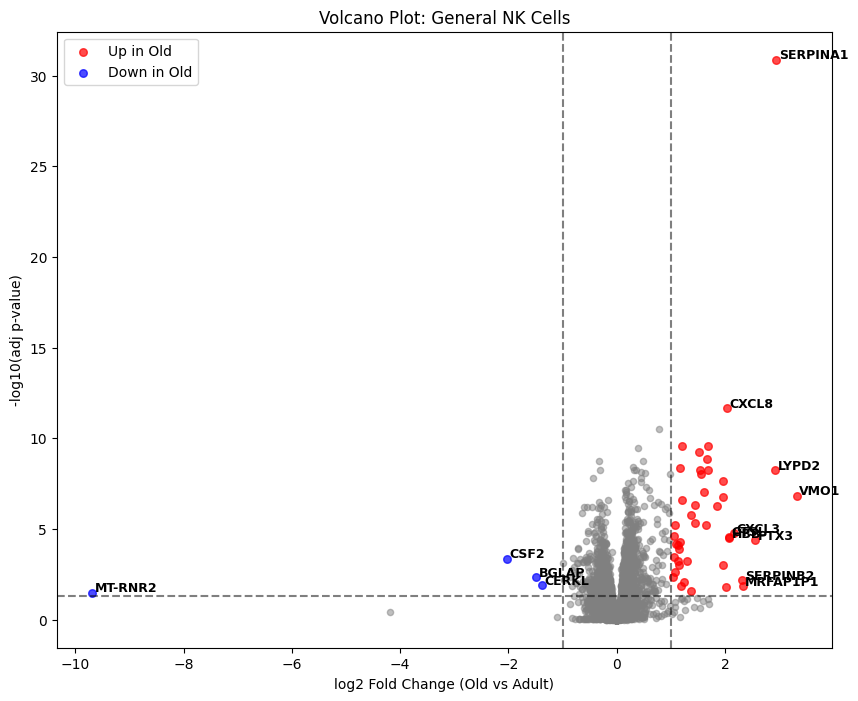

In [7]:
# Visualización: Volcano Plot General
def plot_volcano(res_df, title, lfc_thresh=1.0, output_file=None):
    plt.figure(figsize=(10, 8))
    
    # Calcular -log10 del padj para el eje y (manejando ceros minimos)
    min_nonzero = res_df[res_df['padj'] > 0]['padj'].min()
    if pd.isna(min_nonzero):
        min_nonzero = 1e-300
    y_vals = -np.log10(np.maximum(res_df['padj'], min_nonzero))
    x_vals = res_df['log2FoldChange']
    
    # Colores por significancia
    sig_up = (res_df['padj'] < 0.05) & (res_df['log2FoldChange'] > lfc_thresh)
    sig_down = (res_df['padj'] < 0.05) & (res_df['log2FoldChange'] < -lfc_thresh)
    
    plt.scatter(x_vals[~(sig_up | sig_down)], y_vals[~(sig_up | sig_down)], color='grey', alpha=0.5, s=20)
    plt.scatter(x_vals[sig_up], y_vals[sig_up], color='red', alpha=0.7, s=30, label='Up in Old')
    plt.scatter(x_vals[sig_down], y_vals[sig_down], color='blue', alpha=0.7, s=30, label='Down in Old')
    
    # Líneas de corte
    plt.axhline(-np.log10(0.05), color='k', linestyle='--', alpha=0.5)
    plt.axvline(lfc_thresh, color='k', linestyle='--', alpha=0.5)
    plt.axvline(-lfc_thresh, color='k', linestyle='--', alpha=0.5)
    
    # Anotar top genes
    sig_df = res_df[sig_up | sig_down]
    if len(sig_df) > 0:
        top_up = sig_df[sig_df['log2FoldChange'] > 0].nlargest(10, 'log2FoldChange')
        top_down = sig_df[sig_df['log2FoldChange'] < 0].nsmallest(10, 'log2FoldChange')
        top_genes = pd.concat([top_up, top_down])
        
        # Eliminar duplicados si los hubiera
        top_genes = top_genes[~top_genes.index.duplicated(keep='first')]

        for idx, row in top_genes.iterrows():
            l_val = row['log2FoldChange']
            p_val = -np.log10(max(row['padj'], min_nonzero))
            plt.text(l_val + 0.05, p_val + 0.05, str(idx), fontsize=9, weight='bold')

    plt.title(title)
    plt.xlabel('log2 Fold Change (Old vs Adult)')
    plt.ylabel('-log10(adj p-value)')
    plt.legend()
    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()

plot_volcano(res_gen_clean, 'Volcano Plot: General NK Cells', output_file='results/general_nk_volcano.png')


## 2. Análisis Dinámico por Subtipos Celulares
Evaluaremos la expresión diferencial de manera independiente para cada `cell_type` identificado, utilizando un umbral adaptativo (LFC).

In [8]:
def run_pseudobulk_subtype(adata_full, subtype_name):
    print(f"\n{'='*50}\nIniciando análisis para: {subtype_name}\n{'='*50}")
    
    # Células del subtipo
    adata_sub = adata_full[adata_full.obs['cell_type'] == subtype_name].copy()
    print(f"Tamaño del subset: {adata_sub.n_obs} células")
    
    if adata_sub.n_obs < 150:
        print("Insuficientes células para análisis confiable. Saltando...")
        return None
        
    counts, meta = create_pseudobulk(adata_sub)
    if len(meta) < 3:
        print("Insuficientes donantes. Saltando...")
        return None
        
    if len(meta['age_group'].unique()) < 2:
        print("Solo hay un grupo de edad presente. Saltando para evitar error en DESeq2...")
        return None
        
    counts.index = meta['donor_id']
    meta.index = meta['donor_id']
    
    # Filtrar genes
    genes_keep = (counts > 0).sum(axis=0) >= 1
    counts = counts.loc[:, genes_keep]
    print(f"Pseudobulk final: {counts.shape[0]} donantes, {counts.shape[1]} genes")
    
    # DESeq2
    dds = DeseqDataSet(counts=counts, metadata=meta, design_factors='age_group', 
                       ref_level=['age_group', 'adult'], inference=inference)
    try:
        dds.deseq2()
        stat_res = DeseqStats(dds, inference=inference)
        stat_res.summary()
        return stat_res.results_df
    except Exception as e:
        print(f"Error en DESeq2 para {subtype_name}: {e}")
        return None

def generate_adaptive_report(de_results, subtype_name):
    de_clean = de_results.dropna(subset=['padj']).copy()
    
    # Umbral base
    sig_base = de_clean[(de_clean['padj'] < 0.05) & (abs(de_clean['log2FoldChange']) > 1.0)]
    n_sig = len(sig_base)
    
    # Adaptar umbral
    lfc_threshold = 1.0
    if n_sig > 150:
        lfc_threshold = 1.5
        print(f"[{subtype_name}] Muchos genes significativos ({n_sig}). Aumentando LFC a 1.5.")
    elif n_sig < 10:
        lfc_threshold = 0.5
        print(f"[{subtype_name}] Pocos genes significativos ({n_sig}). Reduciendo LFC a 0.5.")
    else:
        print(f"[{subtype_name}] Número adecuado de genes ({n_sig}). LFC 1.0.")
        
    # Final filtering and display
    sig_final = de_clean[(de_clean['padj'] < 0.05) & (abs(de_clean['log2FoldChange']) > lfc_threshold)]
    print(f"Total genes significativos finales: {len(sig_final)}")
    display(sig_final.sort_values(by='log2FoldChange', ascending=False))
    print("\n")
    
    suffix = str(subtype_name).replace(' ', '_').replace(',', '').replace('/', '_')
    # Exportar
    de_clean.to_csv(f'results/{suffix}_all_results.csv')
    sig_final.to_csv(f'results/{suffix}_significant.csv')
    
    # Plot
    plot_volcano(de_clean, f'Volcano: {subtype_name} (LFC={lfc_threshold})', 
                 lfc_thresh=lfc_threshold, output_file=f'results/{suffix}_volcano.png')


Subtipos detectados: ['natural killer cell', 'CD16-positive, CD56-dim natural killer cell, ..., 'CD16-negative, CD56-bright natural killer cel..., 'type I NK T cell', 'activated type II NK T cell', 'mature NK T cell']
Categories (6, object): ['CD16-negative, CD56-bright natural killer cel..., 'CD16-positive, CD56-dim natural killer cell, ..., 'activated type II NK T cell', 'mature NK T cell', 'natural killer cell', 'type I NK T cell']

Iniciando análisis para: natural killer cell
Tamaño del subset: 67109 células
Pseudobulk final: 454 donantes, 6514 genes


/tmp/ipykernel_7937/4210043049.py:30: UserWarning: Same factor names in the design contain underscores ('_'). They will
                be converted to hyphens ('-').
  dds = DeseqDataSet(counts=counts, metadata=meta, design_factors='age_group',
Fitting size factors...
... done in 0.07 seconds.

Fitting dispersions...
... done in 3.42 seconds.

Fitting dispersion trend curve...
... done in 0.31 seconds.

Fitting MAP dispersions...
... done in 2.09 seconds.

Fitting LFCs...
... done in 2.26 seconds.

Calculating cook's distance...
... done in 0.31 seconds.

Replacing 365 outlier genes.

Fitting dispersions...
... done in 0.21 seconds.

Fitting MAP dispersions...
... done in 0.17 seconds.

Fitting LFCs...
... done in 0.16 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: age-group old vs adult
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
featurekey                                                                   
DPM1         1.557086        0.165113  0.119801  1.378226  0.168133  0.304812
FGR         15.762737        0.019437  0.095360  0.203823  0.838492  0.895592
FUCA2        1.258430        0.052936  0.102238  0.517768  0.604620  0.724261
GCLC         1.309428       -0.142876  0.163963 -0.871390  0.383541  0.529605
NFYA         0.786513       -0.495616  0.171791 -2.884995  0.003914  0.027875
...               ...             ...       ...       ...       ...       ...
NOTCH2NLR    0.008696       -0.848644  2.485795 -0.341397  0.732805       NaN
LINC02680    0.005626       -0.778308  2.492703 -0.312235  0.754862       NaN
COPG2IT1     0.045350       -0.806854  1.498784 -0.538339  0.590343       NaN
GABPB1-IT1   2.696926       -0.805784  0.316504 -2.545888  0.010900  0.051829
PDG

... done in 0.82 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
featurekey,,,,,,
NUGGC,0.193715,-1.004825,0.322256,-3.118097,1.820226e-03,0.017639
ALOX12,0.643388,-1.010147,0.349170,-2.892995,3.815872e-03,0.027423
CCDC18-AS1,3.065181,-1.016280,0.298283,-3.407105,6.565581e-04,0.010024
ESAM,0.845962,-1.027444,0.339641,-3.025087,2.485616e-03,0.021061
SPIN3,0.121234,-1.028981,0.394841,-2.606066,9.158880e-03,0.046563
PCSK6,0.306978,-1.046788,0.352105,-2.972942,2.949601e-03,0.023176
SNHG1,4.478069,-1.048710,0.299332,-3.503497,4.591918e-04,0.008257
EHD3,0.811139,-1.069541,0.261036,-4.097288,4.180180e-05,0.001994
PRR29,0.192829,-1.072433,0.273607,-3.919606,8.869402e-05,0.003143


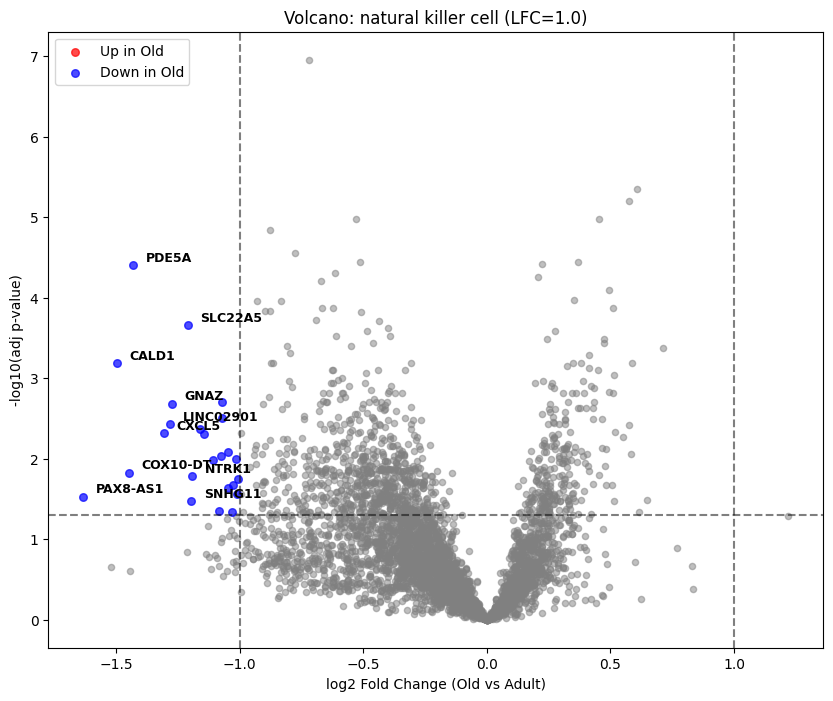


Iniciando análisis para: CD16-positive, CD56-dim natural killer cell, human
Tamaño del subset: 113157 células
Pseudobulk final: 403 donantes, 5611 genes


/tmp/ipykernel_7937/4210043049.py:30: UserWarning: Same factor names in the design contain underscores ('_'). They will
                be converted to hyphens ('-').
  dds = DeseqDataSet(counts=counts, metadata=meta, design_factors='age_group',
Fitting size factors...
... done in 0.07 seconds.

Fitting dispersions...
... done in 2.17 seconds.

Fitting dispersion trend curve...
... done in 0.23 seconds.

Fitting MAP dispersions...
... done in 2.50 seconds.

Fitting LFCs...
... done in 1.46 seconds.

Calculating cook's distance...
... done in 0.26 seconds.

Replacing 83 outlier genes.

Fitting dispersions...
... done in 0.07 seconds.

Fitting MAP dispersions...
... done in 0.07 seconds.

Fitting LFCs...
... done in 0.08 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: age-group old vs adult
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
featurekey                                                                    
DPM1         21.980361       -0.121433  0.055594 -2.184302  0.028940  0.206667
FGR         248.781476       -0.018846  0.066203 -0.284673  0.775895  0.933129
FUCA2        20.165090        0.076670  0.047168  1.625485  0.104059  0.403156
GCLC         21.135145        0.076342  0.082950  0.920328  0.357401  0.702943
NFYA         14.155825       -0.167745  0.067769 -2.475263  0.013314  0.128303
...                ...             ...       ...       ...       ...       ...
NOTCH2NLB     0.126502        0.427323  0.620318  0.688877  0.490900       NaN
NOTCH2NLR     0.082390        0.531026  1.263093  0.420417  0.674181       NaN
LINC02680     0.274119        0.401925  0.367042  1.095040  0.273499  0.633386
COPG2IT1      0.507291        0.318116  0.291811  1.090144  0.275650  

... done in 0.66 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
featurekey,,,,,,
CXCL3,5.883508,5.850352,0.758623,7.711800,1.240558e-14,3.057089e-12
PTX3,2.059487,5.657650,0.952275,5.941194,2.829531e-09,3.571421e-07
VMO1,3.508932,5.582504,0.748136,7.461881,8.529615e-14,1.765630e-11
TNFAIP6,2.319752,5.349270,0.736411,7.263972,3.758852e-13,7.204466e-11
CTSL,4.988195,5.096136,0.465573,10.945937,6.949510e-28,8.990928e-25
SERPINB2,1.963625,5.004686,0.991198,5.049126,4.438354e-07,4.333676e-05
IL6,1.146635,4.663569,1.112519,4.191901,2.766270e-05,1.266854e-03
PID1,2.879299,4.334660,0.416143,10.416279,2.089690e-25,1.625373e-22
SLC15A3,4.343240,3.832569,0.311813,12.291240,1.009458e-34,2.611972e-31


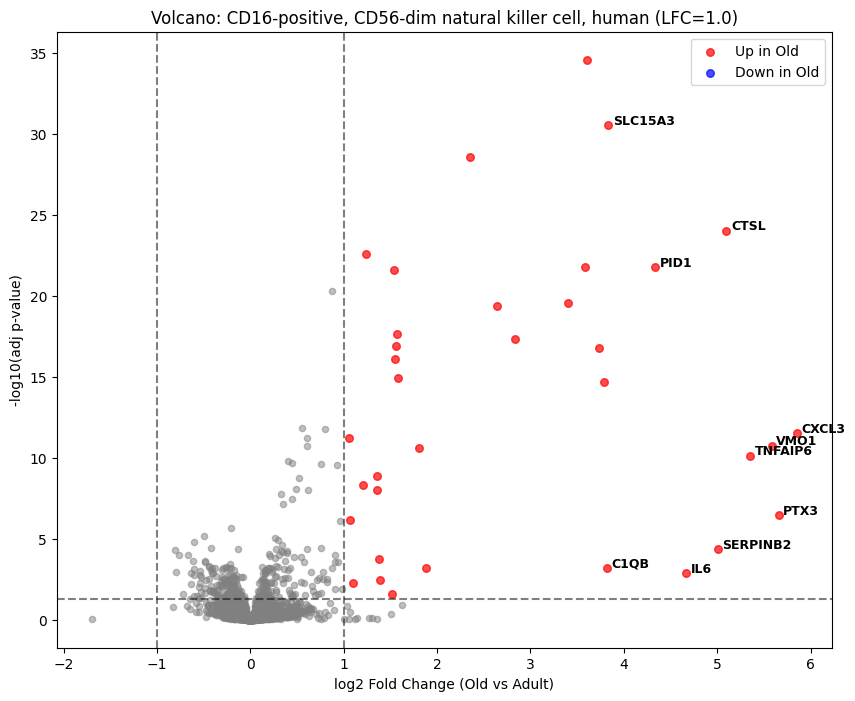


Iniciando análisis para: CD16-negative, CD56-bright natural killer cell, human
Tamaño del subset: 6398 células
Pseudobulk final: 395 donantes, 5466 genes


/tmp/ipykernel_7937/4210043049.py:30: UserWarning: Same factor names in the design contain underscores ('_'). They will
                be converted to hyphens ('-').
  dds = DeseqDataSet(counts=counts, metadata=meta, design_factors='age_group',
Fitting size factors...
... done in 0.06 seconds.

Fitting dispersions...
... done in 1.71 seconds.

Fitting dispersion trend curve...
... done in 0.22 seconds.

Fitting MAP dispersions...
... done in 2.17 seconds.

Fitting LFCs...
... done in 2.08 seconds.

Calculating cook's distance...
... done in 0.36 seconds.

Replacing 16 outlier genes.

Fitting dispersions...
... done in 0.02 seconds.

Fitting MAP dispersions...
... done in 0.02 seconds.

Fitting LFCs...
... done in 0.02 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: age-group old vs adult
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
featurekey                                                                  
DPM1        0.867106       -0.179586  0.191838 -0.936133  0.349205       NaN
FGR         8.839152       -0.018282  0.102384 -0.178563  0.858281  0.957094
FUCA2       1.266603       -0.058069  0.156398 -0.371291  0.710421  0.903482
GCLC        0.674072       -0.319523  0.223568 -1.429199  0.152947       NaN
NFYA        0.606191       -0.239535  0.246942 -0.970003  0.332045       NaN
...              ...             ...       ...       ...       ...       ...
FAM106A     0.041592       -0.156192  1.335103 -0.116989  0.906869       NaN
NOTCH2NLR   0.000060        0.007081  3.715519  0.001906  0.998479       NaN
LINC02680   0.000180        0.012759  3.715405  0.003434  0.997260       NaN
COPG2IT1    0.019130       -0.003986  2.336210 -0.001706  0.998639       NaN
GABPB1-IT1  2.2

... done in 0.74 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
featurekey,,,,,,
CD160,1.346859,0.919037,0.218644,4.203346,0.000026,0.009389
ALOX5AP,1.472089,0.770938,0.206560,3.732262,0.000190,0.027840
SYNE2,2.054922,0.723336,0.208565,3.468161,0.000524,0.048502
SDCBP,1.304573,0.525869,0.141948,3.704669,0.000212,0.027840
PPP2R5C,2.446309,0.516273,0.128949,4.003696,0.000062,0.015235
LMF2,2.213588,-0.507065,0.126587,-4.005677,0.000062,0.015235
POM121,3.045441,-0.521761,0.147898,-3.527856,0.000419,0.040267
GNAS,14.456059,-0.549435,0.141632,-3.879302,0.000105,0.018699
TYK2,1.601709,-0.569456,0.164949,-3.452325,0.000556,0.049603


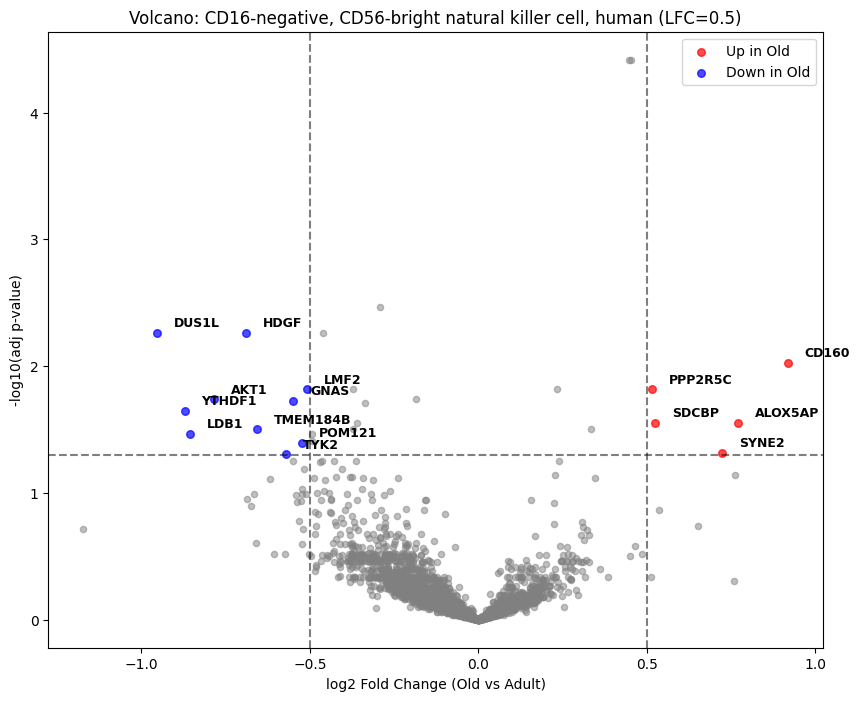


Iniciando análisis para: type I NK T cell
Tamaño del subset: 723 células
Pseudobulk final: 7 donantes, 6120 genes


/tmp/ipykernel_7937/4210043049.py:30: UserWarning: Same factor names in the design contain underscores ('_'). They will
                be converted to hyphens ('-').
  dds = DeseqDataSet(counts=counts, metadata=meta, design_factors='age_group',
Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.30 seconds.

Fitting dispersion trend curve...
/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/pydeseq2/dds.py:727: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.30 seconds.

Fitting MAP dispersions...
... done in 1.60 seconds.

Fitting LFCs...
... done in 1.13 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.63 seconds.



Log2 fold change & Wald test p-value: age-group old vs adult
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
featurekey                                                                   
DPM1         6.599009       -2.563244  0.942073 -2.720855  0.006511  0.047021
FGR         12.359281        0.133538  2.717612  0.049138  0.960809  0.978765
FUCA2        1.766433       -0.439223  1.313548 -0.334379  0.738093       NaN
GCLC         1.522388        0.875516  1.454038  0.602127  0.547089       NaN
NFYA         1.575732       -0.573022  1.114001 -0.514382  0.606985       NaN
...               ...             ...       ...       ...       ...       ...
NOTCH2NLR    0.555286       -4.318228  3.456721 -1.249227  0.211582       NaN
LINC02680    0.010968       -2.212828  4.814230 -0.459643  0.645772       NaN
COPG2IT1     0.628409        0.075385  3.130435  0.024081  0.980788       NaN
GABPB1-IT1   5.262004        1.885146  3.505085  0.537832  0.590693  0.738611
PDG

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
featurekey,,,,,,
ZC3H12A-DT,9.799401,6.269262,1.750687,3.581030,3.422426e-04,0.010759
FCRL6,10.012998,5.959118,1.651170,3.609028,3.073462e-04,0.010759
SERPINI1,6.953863,5.837675,1.545667,3.776800,1.588560e-04,0.007753
SETD1A,4.660977,5.675136,1.816687,3.123893,1.784756e-03,0.025596
TIGD6,3.657529,5.279204,1.821320,2.898559,3.748818e-03,0.036925
UGDH,7.507947,5.025854,1.548143,3.246375,1.168848e-03,0.020929
CRYL1,5.212458,4.946979,1.344464,3.679517,2.336762e-04,0.009784
ZBP1,10.828092,4.882191,1.237051,3.946636,7.925693e-05,0.005214
ZBTB39,2.990129,4.777515,1.770963,2.697693,6.982171e-03,0.048795


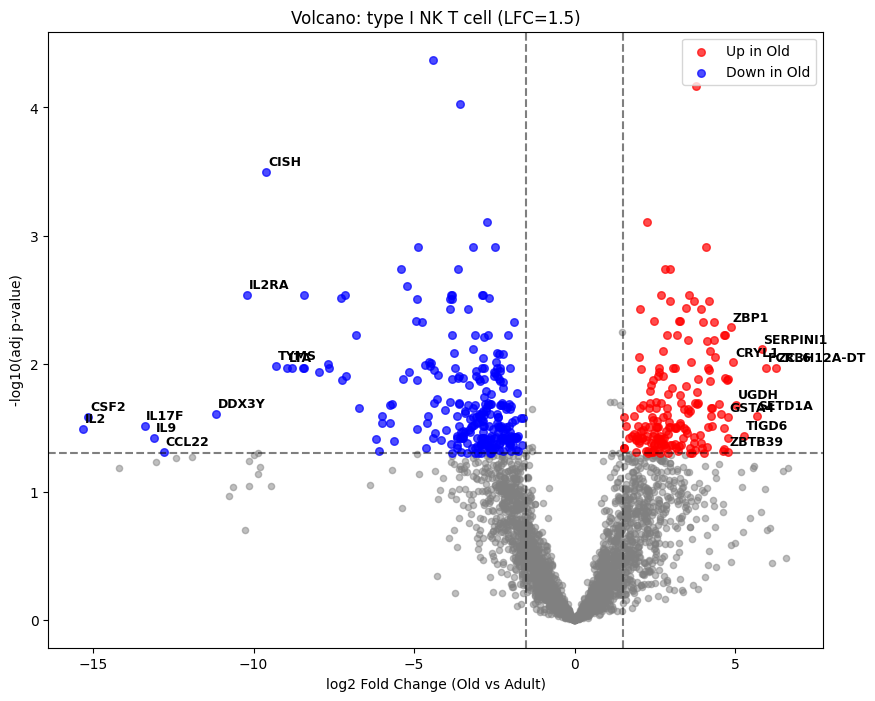


Iniciando análisis para: activated type II NK T cell
Tamaño del subset: 217 células
Solo hay un grupo de edad presente. Saltando para evitar error en DESeq2...

Iniciando análisis para: mature NK T cell
Tamaño del subset: 6097 células
Pseudobulk final: 36 donantes, 6530 genes


/tmp/ipykernel_7937/4210043049.py:30: UserWarning: Same factor names in the design contain underscores ('_'). They will
                be converted to hyphens ('-').
  dds = DeseqDataSet(counts=counts, metadata=meta, design_factors='age_group',
Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 2.10 seconds.

Fitting dispersion trend curve...
/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/pydeseq2/dds.py:727: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.31 seconds.

Fitting MAP dispersions...
... done in 1.99 seconds.

Fitting LFCs...
... done in 1.82 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 1401 outlier genes.

Fitting dispersions...
... done in 0.45 seconds.

Fitting MAP dispersions...
... done in 0.42 seconds.

Fitting LFCs...
... done in 0.50 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: age-group old vs adult
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
featurekey                                                                   
DPM1         5.119542       -0.338439  0.281027 -1.204293  0.228476  0.664022
FGR         95.065555        0.215818  0.357153  0.604274  0.545661  0.750125
FUCA2       10.539364        0.631936  0.445874  1.417297  0.156396  0.664022
GCLC         2.239256        0.330740  0.452065  0.731621  0.464400  0.703927
NFYA         3.433479       -0.453569  0.527991 -0.859047  0.390314  0.666228
...               ...             ...       ...       ...       ...       ...
COPG2IT1     0.048521       -3.199887  2.350124 -1.361582  0.173330  0.664022
GABPB1-IT1   0.720240       -0.964675  2.895194 -0.333199  0.738984  0.870693
PDGFRL2P     0.138556       -3.386970  2.455037 -1.379600  0.167710  0.664022
BMS1P23      0.004551       -2.760094  3.269629 -0.844161  0.398579  0.672363
RNV

... done in 0.78 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
featurekey,,,,,,


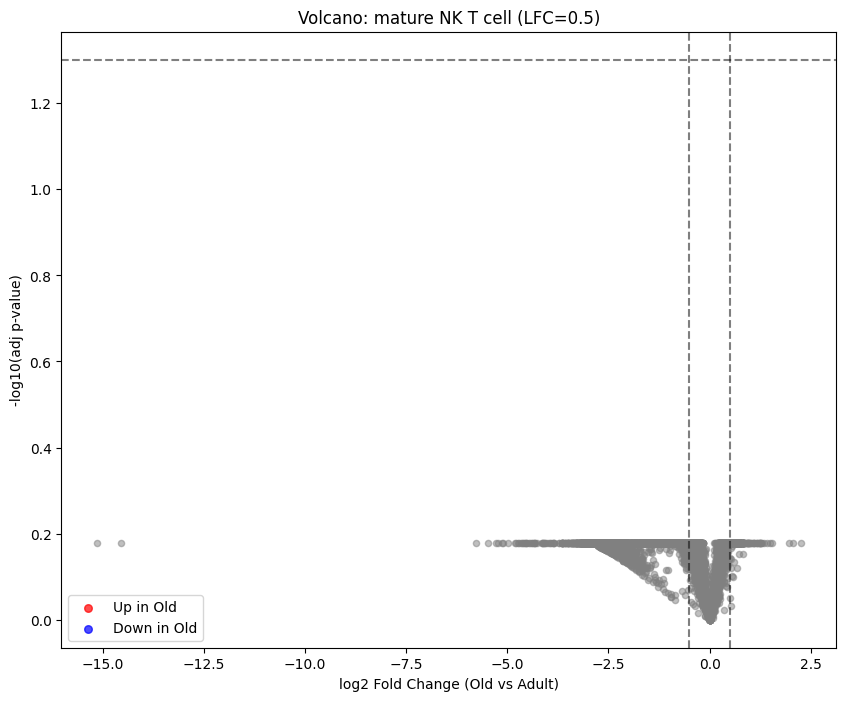

In [9]:
# Recuperar subtipos disponibles (puedes ajustar esta lista si te enfocas solo en ciertos subtipos NK)
subtypes = adata.obs['cell_type'].unique()
print("Subtipos detectados:", subtypes)

for st in subtypes:
    res_df = run_pseudobulk_subtype(adata, st)
    if res_df is not None:
        generate_adaptive_report(res_df, st)


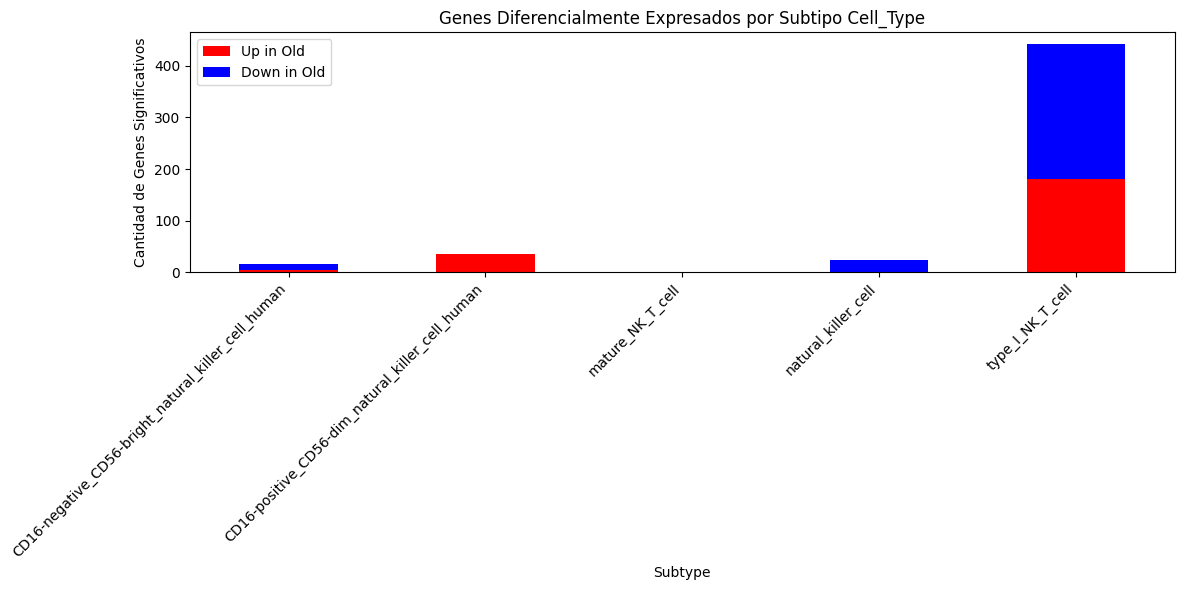

In [10]:
# Resumen Gráfico de los Análisis por Subtipos
import glob

# Leer los reportes guardados
sig_files = glob.glob('results/*_significant.csv')
summary_data = []

for f in sig_files:
    if 'general_nk' in f:
        continue
    df = pd.read_csv(f)
    subtype = os.path.basename(f).replace('_significant.csv', '')
    summary_data.append({
        'Subtype': subtype,
        'Up in Old': len(df[df['log2FoldChange'] > 0]),
        'Down in Old': len(df[df['log2FoldChange'] < 0])
    })

summary_df = pd.DataFrame(summary_data)
if not summary_df.empty:
    summary_df.set_index('Subtype').plot(kind='bar', stacked=True, color=['red', 'blue'], figsize=(12, 6))
    plt.title('Genes Diferencialmente Expresados por Subtipo Cell_Type')
    plt.ylabel('Cantidad de Genes Significativos')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('results/subtypes_summary_barplot.png', dpi=300)
    plt.show()
else:
    print("No se generaron resultados significativos para los subtipos.")
